In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.constants import (
    ORIGINAL_DATA_PATH,
    PREPROCESSING_CATEGORICAL_COLS,
    COLOUR_PALETTE,
    VAL_QUARTERS,
    VAL_YEAR,
    TEST_YEAR,
    TRAIN_YEARS
)
from src.preprocessing import (
    load_original_dataset,
    filter_to_health_sector,
    filter_to_timeframe,
    set_categorical_dtypes,
)
from src.visualisations import (
    plot_vertical_bar_chart,
    plot_pie_chart,
    plot_horizontal_stacked_crosstab,
    plot_vertical_stacked_crosstab,
)

In [2]:
df_original = load_original_dataset(ORIGINAL_DATA_PATH)
df_original.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206140 entries, 0 to 206139
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   BI Reference                206140 non-null  object
 1   Year                        206140 non-null  int64 
 2   Quarter                     206140 non-null  object
 3   Data Subject Type           206140 non-null  object
 4   Data Type                   206140 non-null  object
 5   Decision Taken              206140 non-null  object
 6   Incident Category           206140 non-null  object
 7   Incident Type               206140 non-null  object
 8   No. Data Subjects Affected  206140 non-null  object
 9   Sector                      206140 non-null  object
 10  Time Taken to Report        206140 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.3+ MB


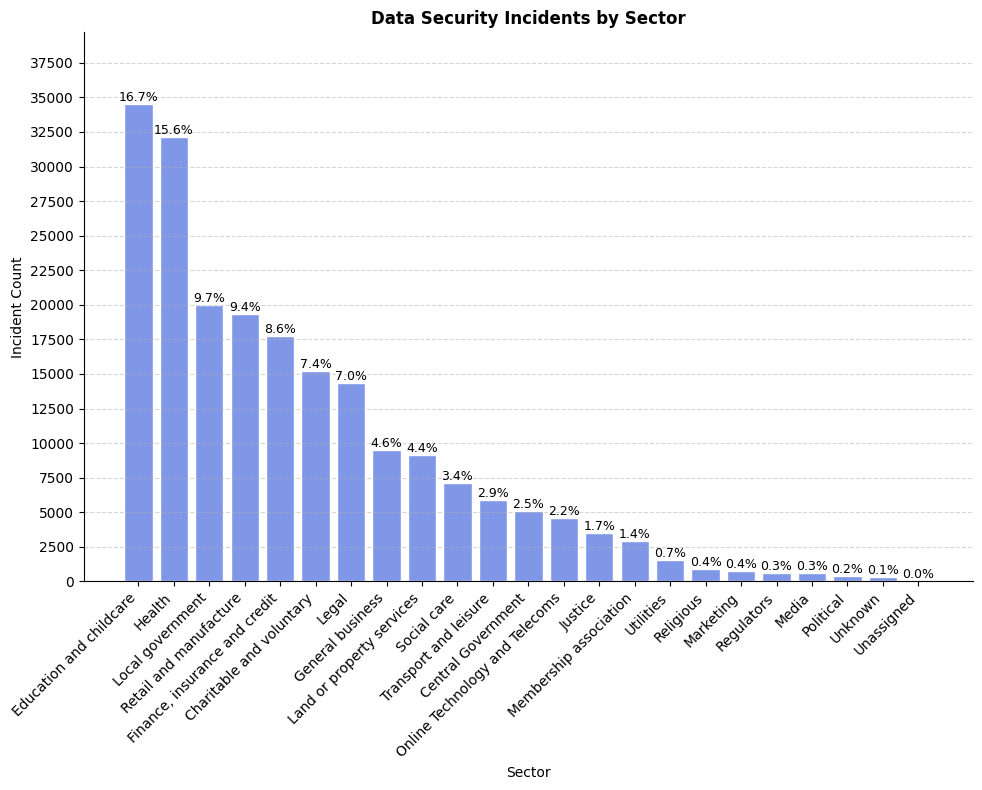


Total sectors: 23
                                count  percentage
Sector                                           
Education and childcare         34525   16.748326
Health                          32127   15.585039
Local government                19991    9.697778
Retail and manufacture          19308    9.366450
Finance, insurance and credit   17744    8.607742
Charitable and voluntary        15229    7.387698
Legal                           14329    6.951101
General business                 9520    4.618221
Land or property services        9148    4.437761
Social care                      7103    3.445717
Transport and leisure            5908    2.866013
Central Government               5054    2.451732
Online Technology and Telecoms   4614    2.238285
Justice                          3503    1.699331
Membership association           2937    1.424760
Utilities                        1536    0.745125
Religious                         894    0.433686
Marketing                      

In [3]:
sector_counts = df_original["Sector"].value_counts()
sector_summary = plot_vertical_bar_chart(
    sector_counts,
    title="Data Security Incidents by Sector",
    xlabel="Sector",
    ylabel="Incident Count",
    sort_by="none",
    figsize=(10, 8),
    annotate="percentage",
    colour="#8097e8",
    step=2500,
)
print(f"\nTotal sectors: {df_original['Sector'].nunique()}")
print(sector_summary)

In [4]:
df_health_original = filter_to_health_sector(df_original)
df_health_original.info()
df_health_original = filter_to_timeframe(df_health_original, 2021, 2, 2025, 4)

df_health_original = set_categorical_dtypes(df_health_original)
df_health_original.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32127 entries, 12 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   bi_reference               32127 non-null  object
 1   year                       32127 non-null  int64 
 2   quarter                    32127 non-null  object
 3   data_subject_type          32127 non-null  object
 4   data_type                  32127 non-null  object
 5   decision_taken             32127 non-null  object
 6   incident_category          32127 non-null  object
 7   incident_type              32127 non-null  object
 8   no_data_subjects_affected  32127 non-null  object
 9   time_taken_to_report       32127 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 22879 entries, 65264 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------       

In [5]:
total_rows = len(df_health_original)
unique_bi_refs = df_health_original["bi_reference"].nunique()
duplicate_ratio = (total_rows - unique_bi_refs) / total_rows * 100

print(f"Total rows in the dataset: {total_rows:,}")
print(f"Unique BI References: {unique_bi_refs:,}")
print(f"Rows representing duplicate characteristics: {total_rows - unique_bi_refs:,}")
print(f"Duplication rate: {duplicate_ratio:.2f}%")

Total rows in the dataset: 22,879
Unique BI References: 10,098
Rows representing duplicate characteristics: 12,781
Duplication rate: 55.86%


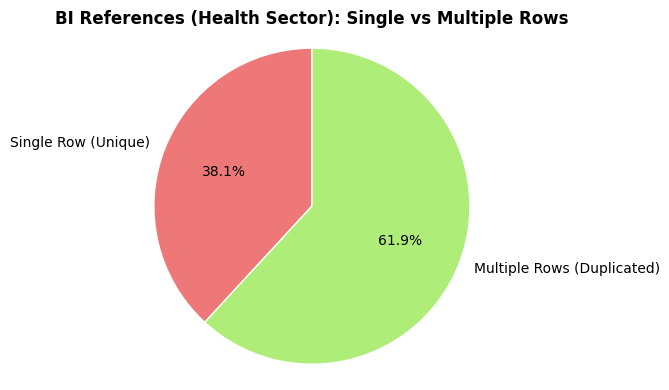

                            count  percentage
Single Row (Unique)          3851        38.1
Multiple Rows (Duplicated)   6247        61.9


In [6]:
bi_ref_counts = df_health_original["bi_reference"].value_counts()
bi_ref_series = pd.Series({
    "Single Row (Unique)":       (bi_ref_counts == 1).sum(),
    "Multiple Rows (Duplicated)": (bi_ref_counts > 1).sum(),
})

bi_ref_summary = plot_pie_chart(
    bi_ref_series,
    title="BI References (Health Sector): Single vs Multiple Rows",
    total=bi_ref_series.sum(),
)
print(bi_ref_summary)

In [7]:
duplicated_bi_refs = df_health_original[df_health_original["bi_reference"].duplicated(keep=False)]
total_groups = duplicated_bi_refs["bi_reference"].nunique()

# nunique per group per column
varying_columns = duplicated_bi_refs.groupby("bi_reference", observed=False).nunique()

# A column varies in a group if nunique > 1
varying_counts = (varying_columns > 1).sum()

varying_counts = (
    varying_counts
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)
varying_counts["percentage"] = (varying_counts["count"] / total_groups * 100)

print(f"Columns that vary across duplicate rows:\n {varying_counts}")
print("\nBreach characteristics per incident:")
print(df_health_original.groupby("bi_reference", observed=False).size().describe())

Columns that vary across duplicate rows:
                            count  percentage
data_type                   5675   90.843605
data_subject_type           1689   27.036978
year                           0    0.000000
quarter                        0    0.000000
decision_taken                 0    0.000000
incident_category              0    0.000000
incident_type                  0    0.000000
no_data_subjects_affected      0    0.000000
time_taken_to_report           0    0.000000

Breach characteristics per incident:
count    10098.000000
mean         2.265696
std          2.808294
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         66.000000
dtype: float64


In [8]:
df_health_unique = df_health_original.drop_duplicates(subset=["bi_reference"], keep="first").reset_index(drop=True)
print(f"Unique rows in health sector df: {len(df_health_unique)}")

# Remove rows with "Not Yet Assigned" in decision_taken"
df_health_unique = df_health_unique[df_health_unique["decision_taken"] != "Not Yet Assigned"].reset_index(drop=True)
print(f"Rows after removing 'Not Yet Assigned': {len(df_health_unique)}")

Unique rows in health sector df: 10098
Rows after removing 'Not Yet Assigned': 9250


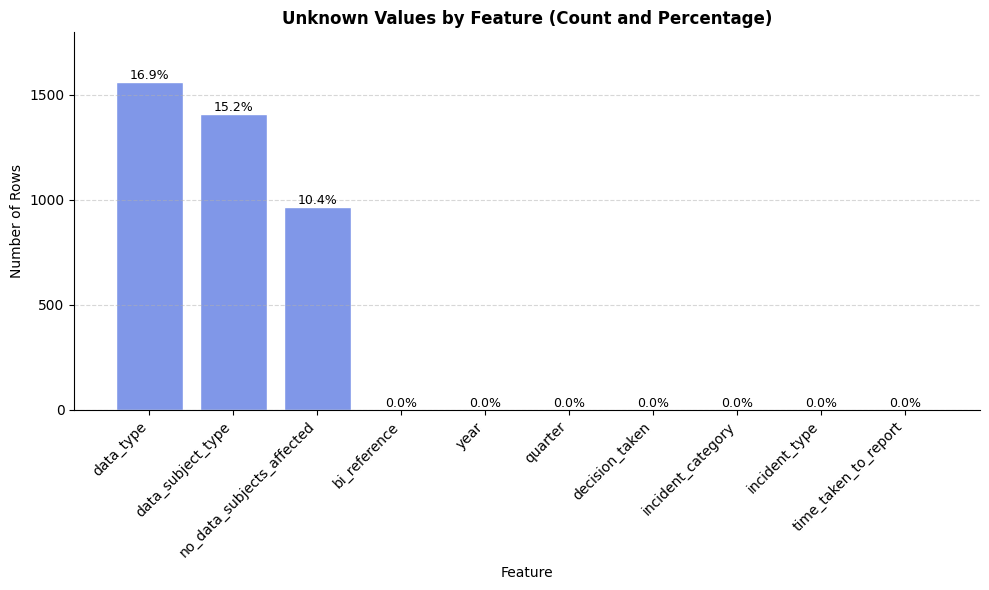

                           count  percentage
data_type                   1562   16.886486
data_subject_type           1410   15.243243
no_data_subjects_affected    966   10.443243
bi_reference                   0    0.000000
year                           0    0.000000
quarter                        0    0.000000
decision_taken                 0    0.000000
incident_category              0    0.000000
incident_type                  0    0.000000
time_taken_to_report           0    0.000000


In [9]:
unknown_counts = (
    df_health_unique[PREPROCESSING_CATEGORICAL_COLS]
    .isin(["Unknown"]).sum()
    .sort_values(ascending=False)
)
unknown_summary = plot_vertical_bar_chart(
    unknown_counts,
    title="Unknown Values by Feature (Count and Percentage)",
    xlabel="Feature",
    ylabel="Number of Rows",
    sort_by="none",
    total=len(df_health_unique),
    annotate="percentage",
    colour="#8097e8",
    step=500,
)
print(unknown_summary)

In [10]:
# Aggregate total rows per year-quarter (duplicated BI references)
total_incidents = (
    df_health_original
    .groupby(["year", "quarter"], observed=True)
    .size()
    .reset_index(name="total_incidents")
)

# Aggregate unique incidents per year-quarter
unique_incidents = (
    df_health_unique
    .groupby(["year", "quarter"], observed=True)
    .size()
    .reset_index(name="unique_incidents")
)

quarter_to_num = {"Qtr 1": 1, "Qtr 2": 2, "Qtr 3": 3, "Qtr 4": 4}

incidents_over_time = total_incidents.merge(unique_incidents, on=["year", "quarter"])
incidents_over_time["quarter_num"] = incidents_over_time["quarter"].astype(str).map(quarter_to_num)
incidents_over_time["year_num"] = incidents_over_time["year"].astype(str).astype(int)
incidents_over_time = incidents_over_time.sort_values(by=["year_num", "quarter_num"]).reset_index(drop=True)
incidents_over_time["period"] = (incidents_over_time["year"].astype(str) + " " + incidents_over_time["quarter"].astype(str))

# Display table with both totals and a duplicate count
display_df = incidents_over_time[["year", "quarter", "total_incidents", "unique_incidents"]].copy()
display_df["duplicates"] = display_df["total_incidents"] - display_df["unique_incidents"]
display_df.columns = ["Year", "Quarter", "Total Rows", "Unique Incidents", "Duplicates"]

print("Healthcare data security incidents over time:")
print(display_df.to_string(index=False))

print(f"\nOverall Summary:")
print(f"\tTotal rows across all periods: {display_df['Total Rows'].sum():,}")
print(f"\tTotal unique incidents: {display_df['Unique Incidents'].sum():,}")
print(f"\tTotal duplicate incidents: {display_df['Duplicates'].sum():,}")

Healthcare data security incidents over time:
Year Quarter  Total Rows  Unique Incidents  Duplicates
2021   Qtr 2        1286               603         683
2021   Qtr 3         915               432         483
2021   Qtr 4         991               461         530
2022   Qtr 1         913               421         492
2022   Qtr 2         937               431         506
2022   Qtr 3        1548               481        1067
2022   Qtr 4         938               440         498
2023   Qtr 1        1077               454         623
2023   Qtr 2        1019               458         561
2023   Qtr 3        1038               501         537
2023   Qtr 4        1191               439         752
2024   Qtr 1        1245               510         735
2024   Qtr 2        1497               534         963
2024   Qtr 3        1620               601        1019
2024   Qtr 4        1154               546         608
2025   Qtr 1        1231               533         698
2025   Qtr 2       

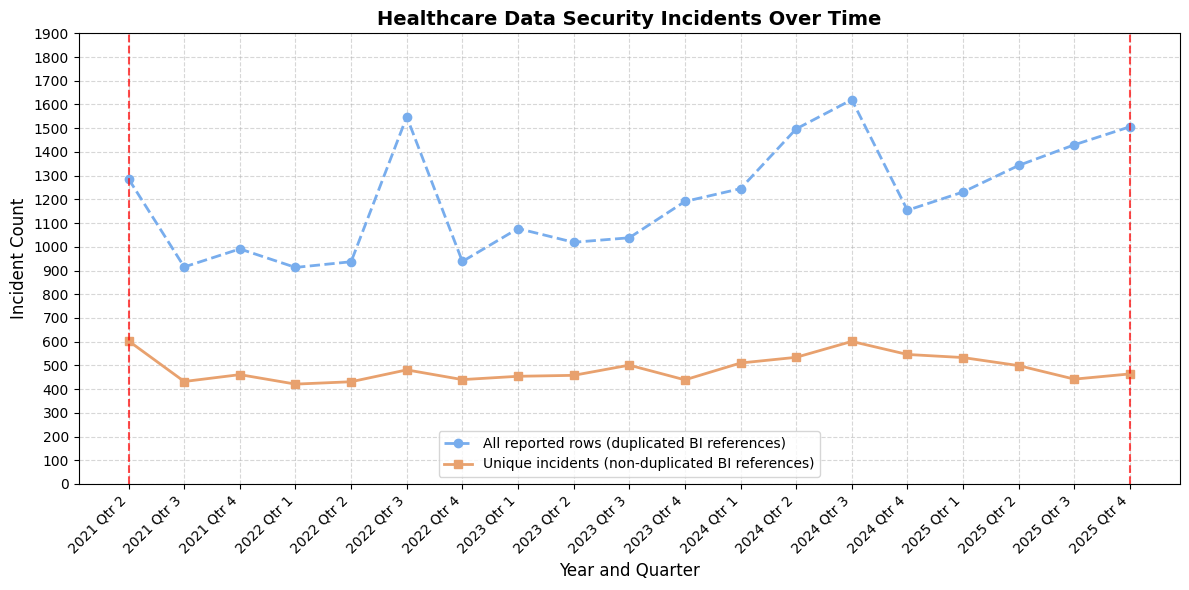

In [11]:
# Line chart of incidents over time
plt.figure(figsize=(12, 6))
plt.plot(
    incidents_over_time.index,
    incidents_over_time["total_incidents"],
    marker="o", label="All reported rows (duplicated BI references)",
    linestyle="--", linewidth=2, markersize=6, color="#78ADED",
)
plt.plot(
    incidents_over_time.index,
    incidents_over_time["unique_incidents"],
    marker="s", label="Unique incidents (non-duplicated BI references)",
    linewidth=2, markersize=6, color="#e8a16e",
)
plt.xticks(
    ticks=incidents_over_time.index,
    labels=incidents_over_time["period"],
    rotation=45, ha="right",
)
plt.yticks(np.arange(0, incidents_over_time["total_incidents"].max() * 1.2, 100))
plt.title("Healthcare Data Security Incidents Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year and Quarter", fontsize=12)
plt.ylabel("Incident Count", fontsize=12)

# Lines marking the start and end of the temporal range Q2 2021 to Q4 2025
start_of_range_index = incidents_over_time[(incidents_over_time["year"] == 2021) & (incidents_over_time["quarter"] == "Qtr 2")].index[0]
end_of_range_index = incidents_over_time[(incidents_over_time["year"] == 2025) & (incidents_over_time["quarter"] == "Qtr 4")].index[0]
plt.axvline(x=start_of_range_index, color="red", linestyle="--", alpha=0.7)
plt.axvline(x=end_of_range_index, color="red", linestyle="--", alpha=0.7)

plt.legend(loc="best", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

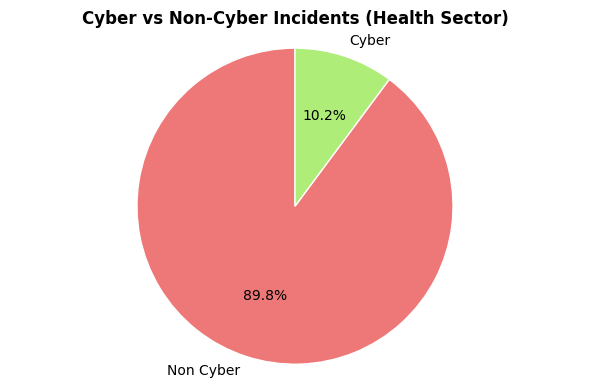

                   count  percentage
incident_category                   
Non Cyber           8309        89.8
Cyber                941        10.2


In [12]:
# Cyber vs Non-Cyber incidents
incident_category_counts = df_health_unique["incident_category"].value_counts()
incident_category_summary = plot_pie_chart(
    incident_category_counts,
    title="Cyber vs Non-Cyber Incidents (Health Sector)",
    total=len(df_health_unique),
    colours=COLOUR_PALETTE[:2],
)
print(incident_category_summary)

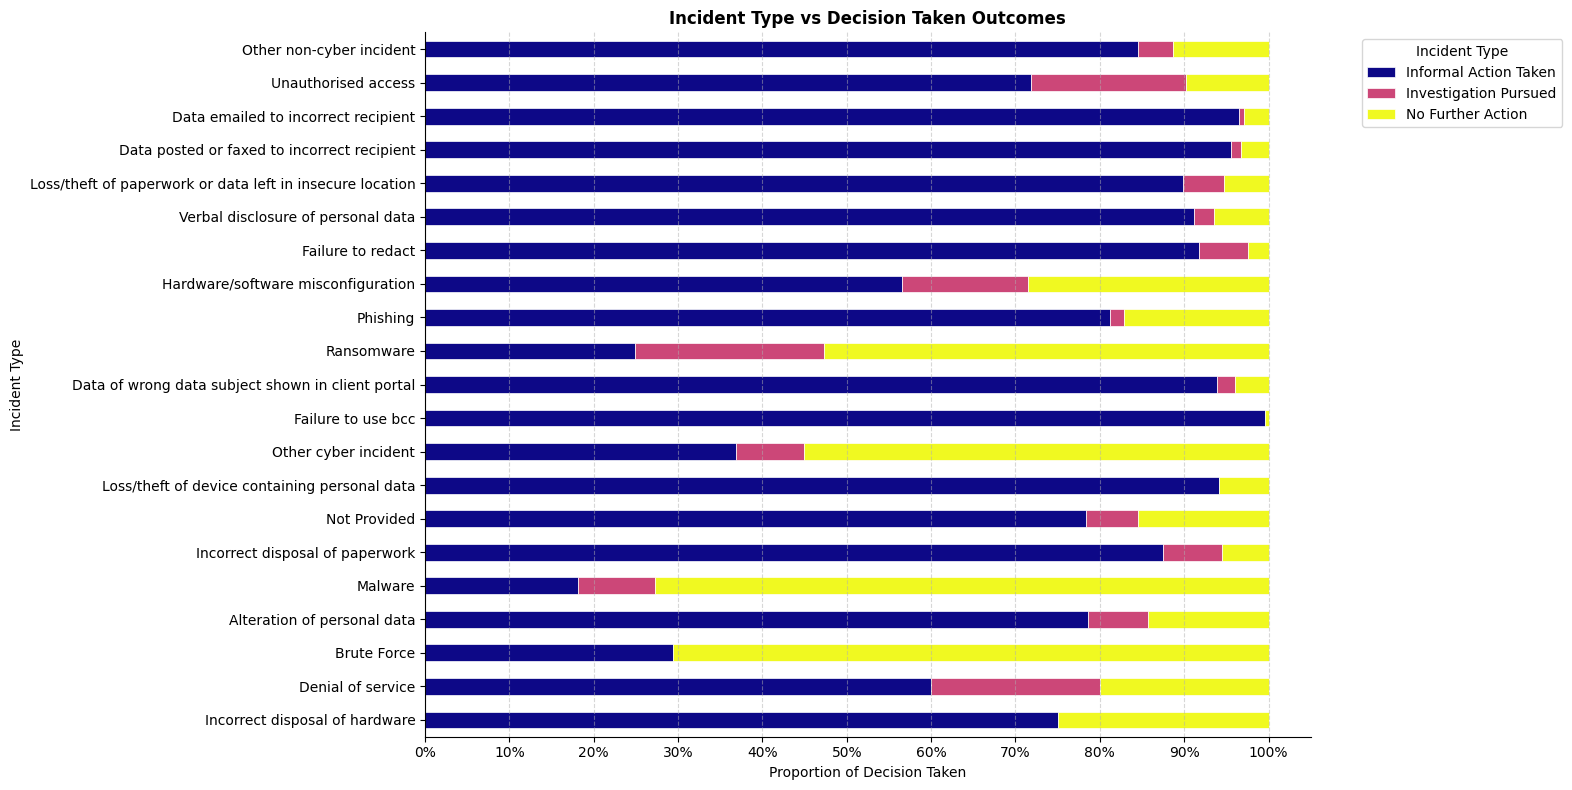

decision_taken                                      Informal Action Taken  \
incident_type                                                               
Incorrect disposal of hardware                                      0.750   
Denial of service                                                   0.600   
Brute Force                                                         0.294   
Alteration of personal data                                         0.786   
Malware                                                             0.182   
Incorrect disposal of paperwork                                     0.875   
Not Provided                                                        0.784   
Loss/theft of device containing personal data                       0.942   
Other cyber incident                                                0.368   
Failure to use bcc                                                  0.995   
Data of wrong data subject shown in client portal                   0.940   

In [13]:
# Incident type vs decision taken
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["incident_type"],
    df_health_unique["decision_taken"],
    title="Incident Type vs Decision Taken Outcomes",
    xlabel="Decision Taken",
    ylabel="Incident Type",
)
print(proportions)

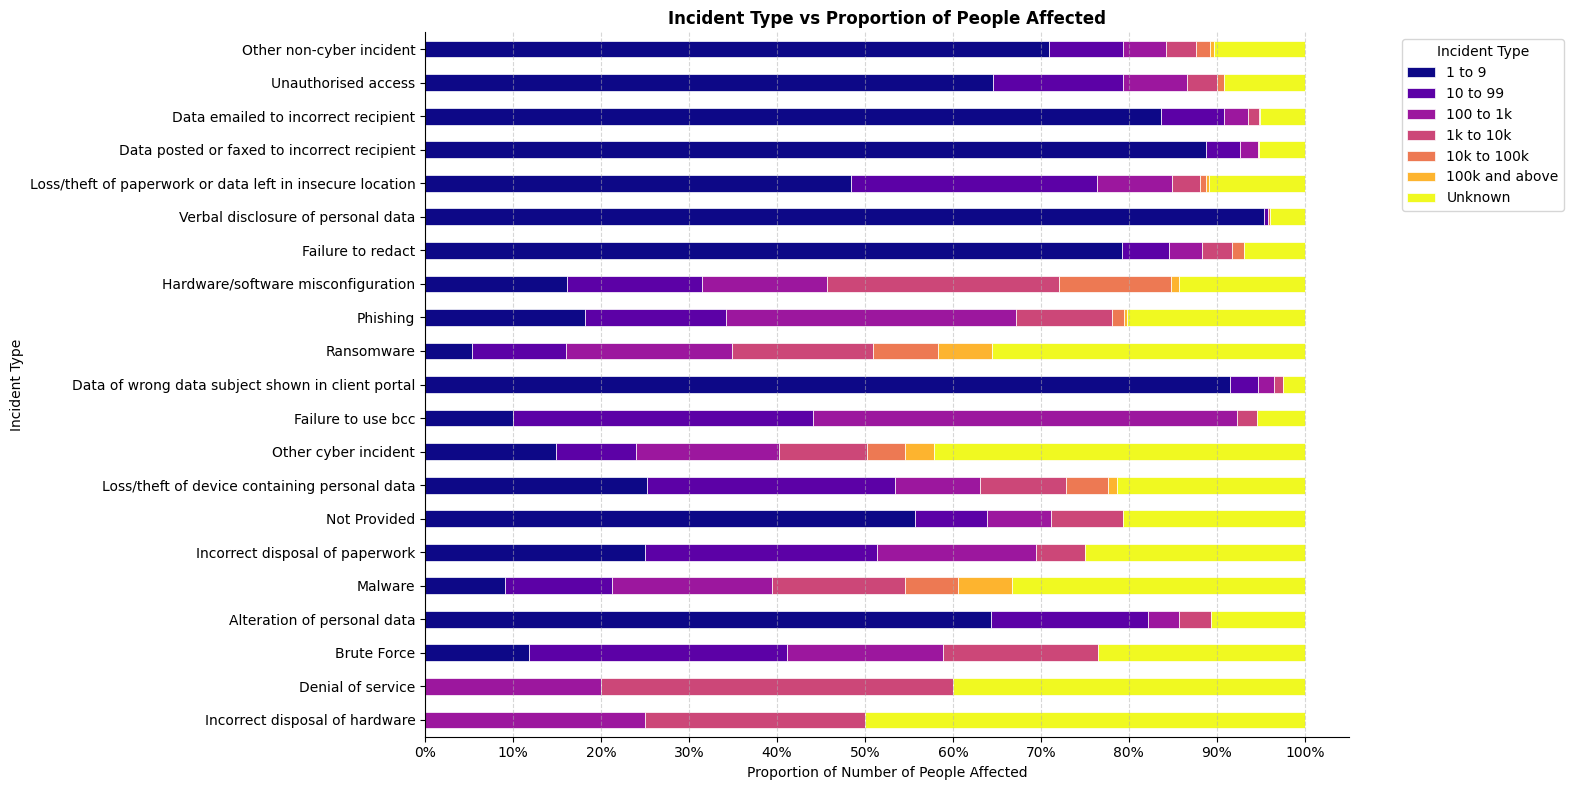

no_data_subjects_affected                           1 to 9  10 to 99  \
incident_type                                                          
Incorrect disposal of hardware                       0.000     0.000   
Denial of service                                    0.000     0.000   
Brute Force                                          0.118     0.294   
Alteration of personal data                          0.643     0.179   
Malware                                              0.091     0.121   
Incorrect disposal of paperwork                      0.250     0.264   
Not Provided                                         0.557     0.082   
Loss/theft of device containing personal data        0.252     0.282   
Other cyber incident                                 0.148     0.091   
Failure to use bcc                                   0.100     0.341   
Data of wrong data subject shown in client portal    0.915     0.032   
Ransomware                                           0.053     0

In [14]:
# Incident type vs number of people affected
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["incident_type"],
    df_health_unique["no_data_subjects_affected"],
    title="Incident Type vs Proportion of People Affected",
    xlabel="Number of People Affected",
    ylabel="Incident Type",
)
print(proportions)

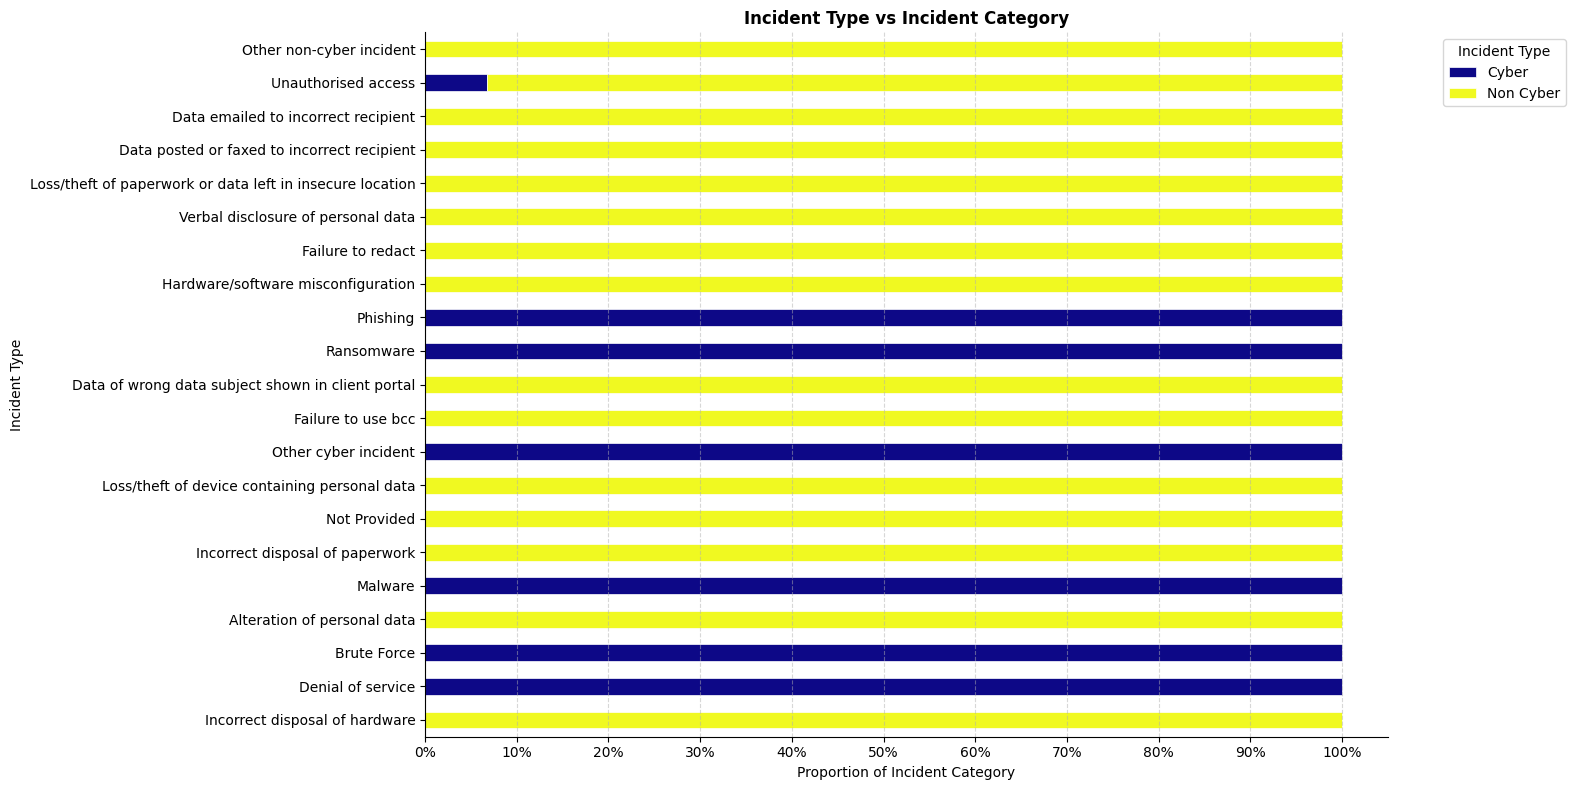

incident_category                                   Cyber  Non Cyber
incident_type                                                       
Incorrect disposal of hardware                      0.000      1.000
Denial of service                                   1.000      0.000
Brute Force                                         1.000      0.000
Alteration of personal data                         0.000      1.000
Malware                                             1.000      0.000
Incorrect disposal of paperwork                     0.000      1.000
Not Provided                                        0.000      1.000
Loss/theft of device containing personal data       0.000      1.000
Other cyber incident                                1.000      0.000
Failure to use bcc                                  0.000      1.000
Data of wrong data subject shown in client portal   0.000      1.000
Ransomware                                          1.000      0.000
Phishing                          

In [15]:
# Incident type vs incident category
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["incident_type"],
    df_health_unique["incident_category"],
    title="Incident Type vs Incident Category",
    xlabel="Incident Category",
    ylabel="Incident Type",
)
print(proportions)

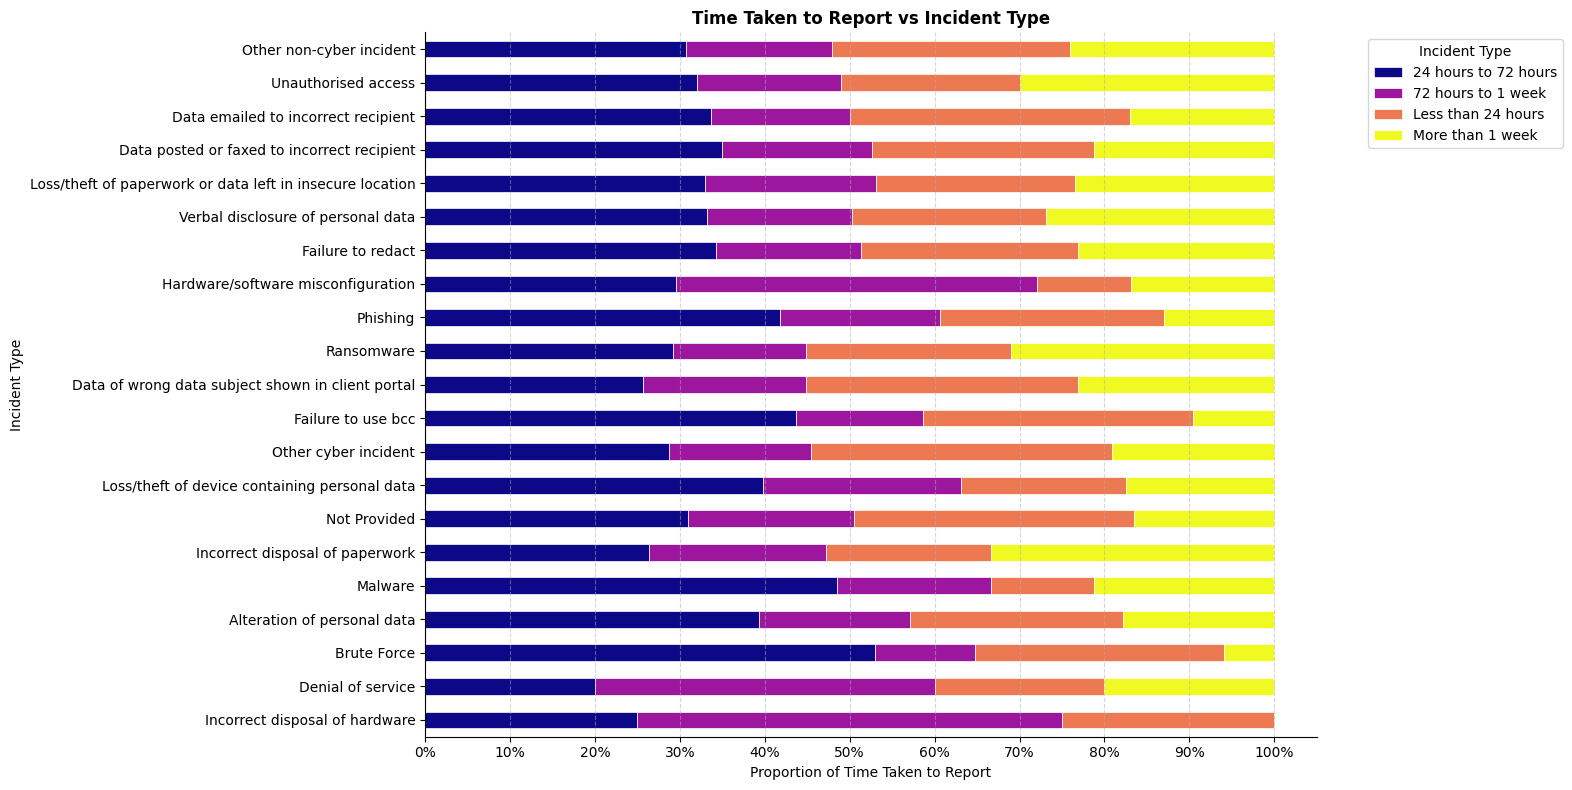

time_taken_to_report                                24 hours to 72 hours  \
incident_type                                                              
Incorrect disposal of hardware                                     0.250   
Denial of service                                                  0.200   
Brute Force                                                        0.529   
Alteration of personal data                                        0.393   
Malware                                                            0.485   
Incorrect disposal of paperwork                                    0.264   
Not Provided                                                       0.309   
Loss/theft of device containing personal data                      0.398   
Other cyber incident                                               0.287   
Failure to use bcc                                                 0.436   
Data of wrong data subject shown in client portal                  0.256   
Ransomware  

In [16]:
# Time taken to report vs incident type
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["incident_type"],
    df_health_unique["time_taken_to_report"],
    title="Time Taken to Report vs Incident Type",
    xlabel="Time Taken to Report",
    ylabel="Incident Type",
)
print(proportions)

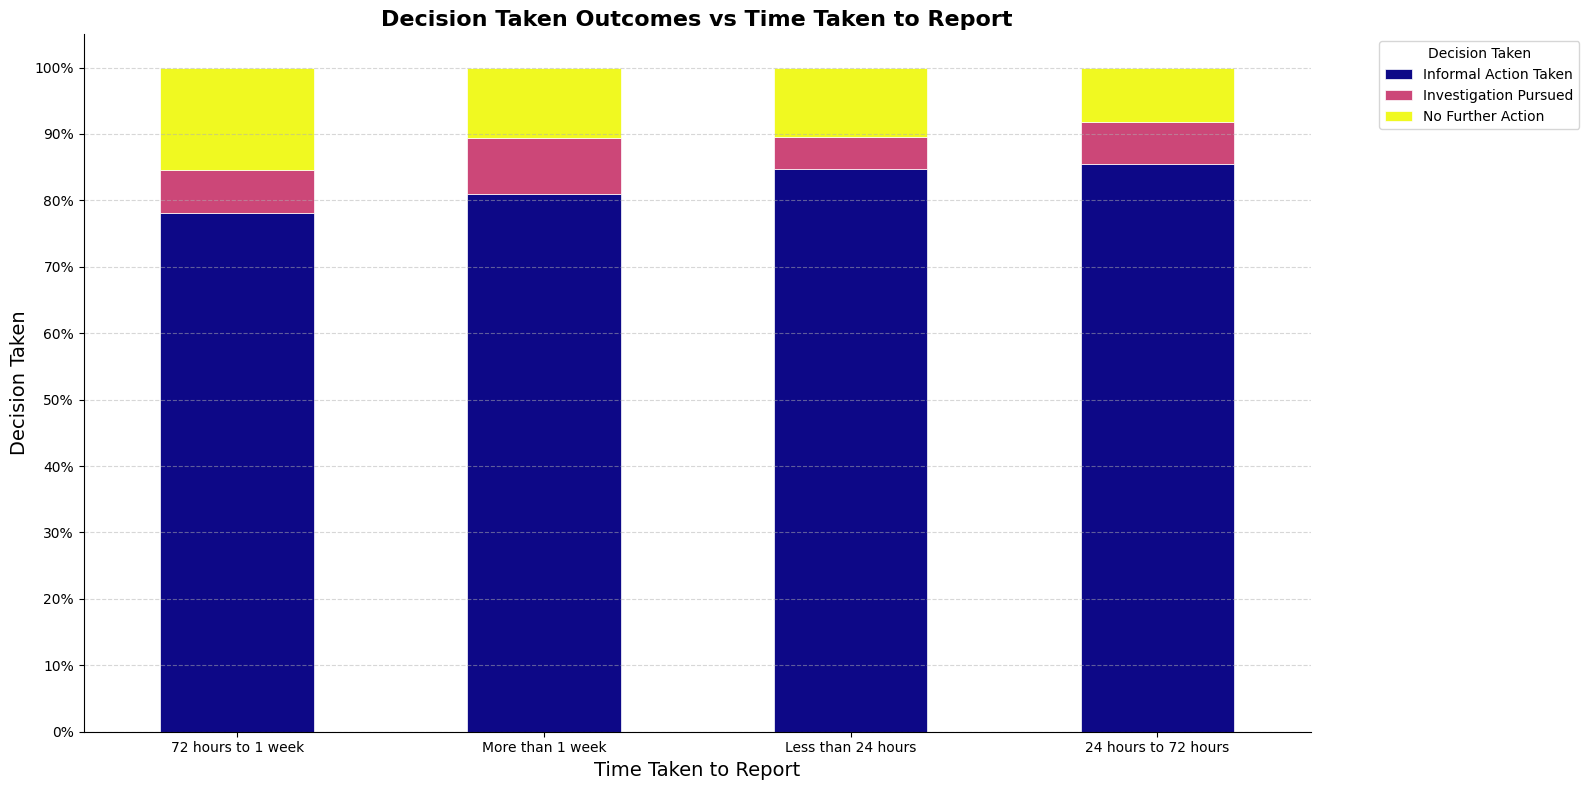

decision_taken        Informal Action Taken  Investigation Pursued  \
time_taken_to_report                                                 
72 hours to 1 week                    0.782                  0.064   
More than 1 week                      0.809                  0.085   
Less than 24 hours                    0.847                  0.049   
24 hours to 72 hours                  0.855                  0.064   

decision_taken        No Further Action  
time_taken_to_report                     
72 hours to 1 week                0.154  
More than 1 week                  0.106  
Less than 24 hours                0.104  
24 hours to 72 hours              0.081  


In [17]:
# Decision taken vs time taken to report
proportions, counts = plot_vertical_stacked_crosstab(
    df_health_unique["time_taken_to_report"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Time Taken to Report",
    xlabel="Decision Taken",
    ylabel="Time Taken to Report",
)
print(proportions)

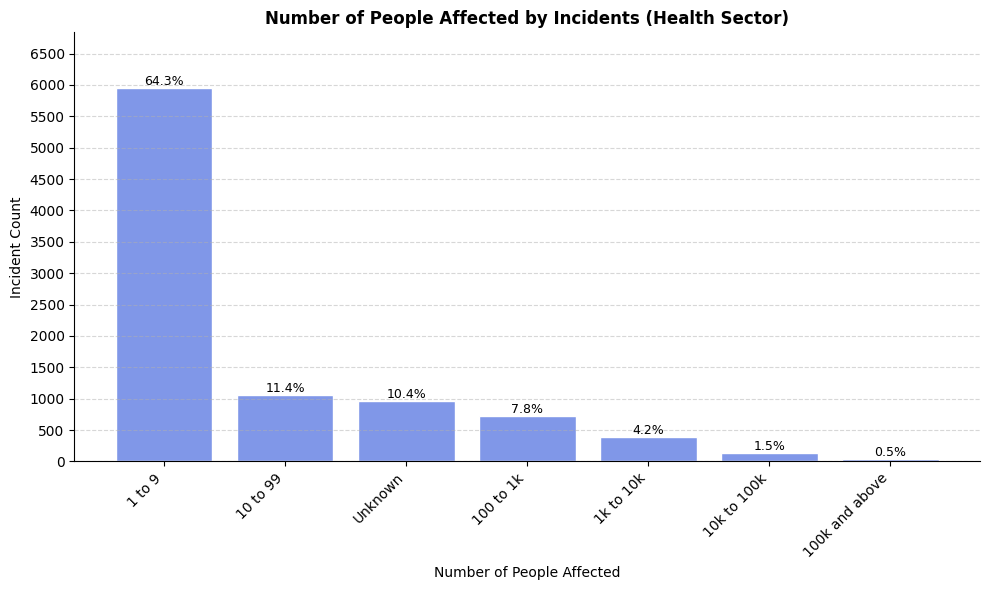

                           count  percentage
no_data_subjects_affected                   
1 to 9                      5946   64.281081
10 to 99                    1052   11.372973
Unknown                      966   10.443243
100 to 1k                    718    7.762162
1k to 10k                    389    4.205405
10k to 100k                  135    1.459459
100k and above                44    0.475676


In [18]:
# Number of people affected (Health sector)
people_summary = plot_vertical_bar_chart(
    df_health_unique["no_data_subjects_affected"].value_counts(),
    title="Number of People Affected by Incidents (Health Sector)",
    xlabel="Number of People Affected",
    ylabel="Incident Count",
    sort_by="none",
    annotate="percent",
    colour="#8097e8",
    step=500,
)
print(people_summary)

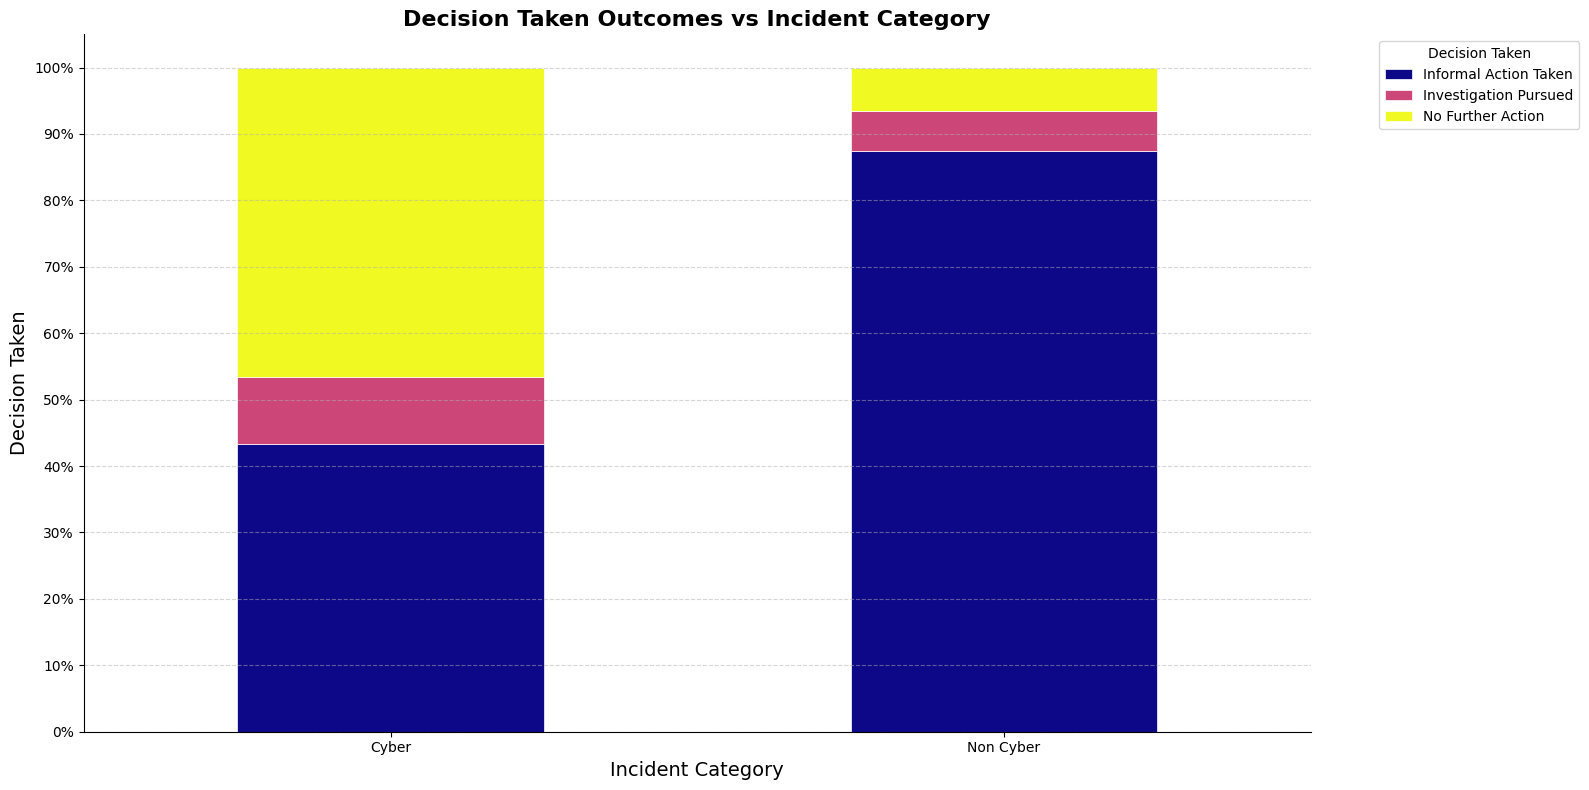

decision_taken     Informal Action Taken  Investigation Pursued  \
incident_category                                                 
Cyber                              0.434                  0.101   
Non Cyber                          0.874                  0.061   

decision_taken     No Further Action  
incident_category                     
Cyber                          0.465  
Non Cyber                      0.065  


In [19]:
# Decision taken vs incident category
proportions, counts = plot_vertical_stacked_crosstab(
    df_health_unique["incident_category"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Incident Category",
    xlabel="Decision Taken",
    ylabel="Incident Category",
)
print(proportions)

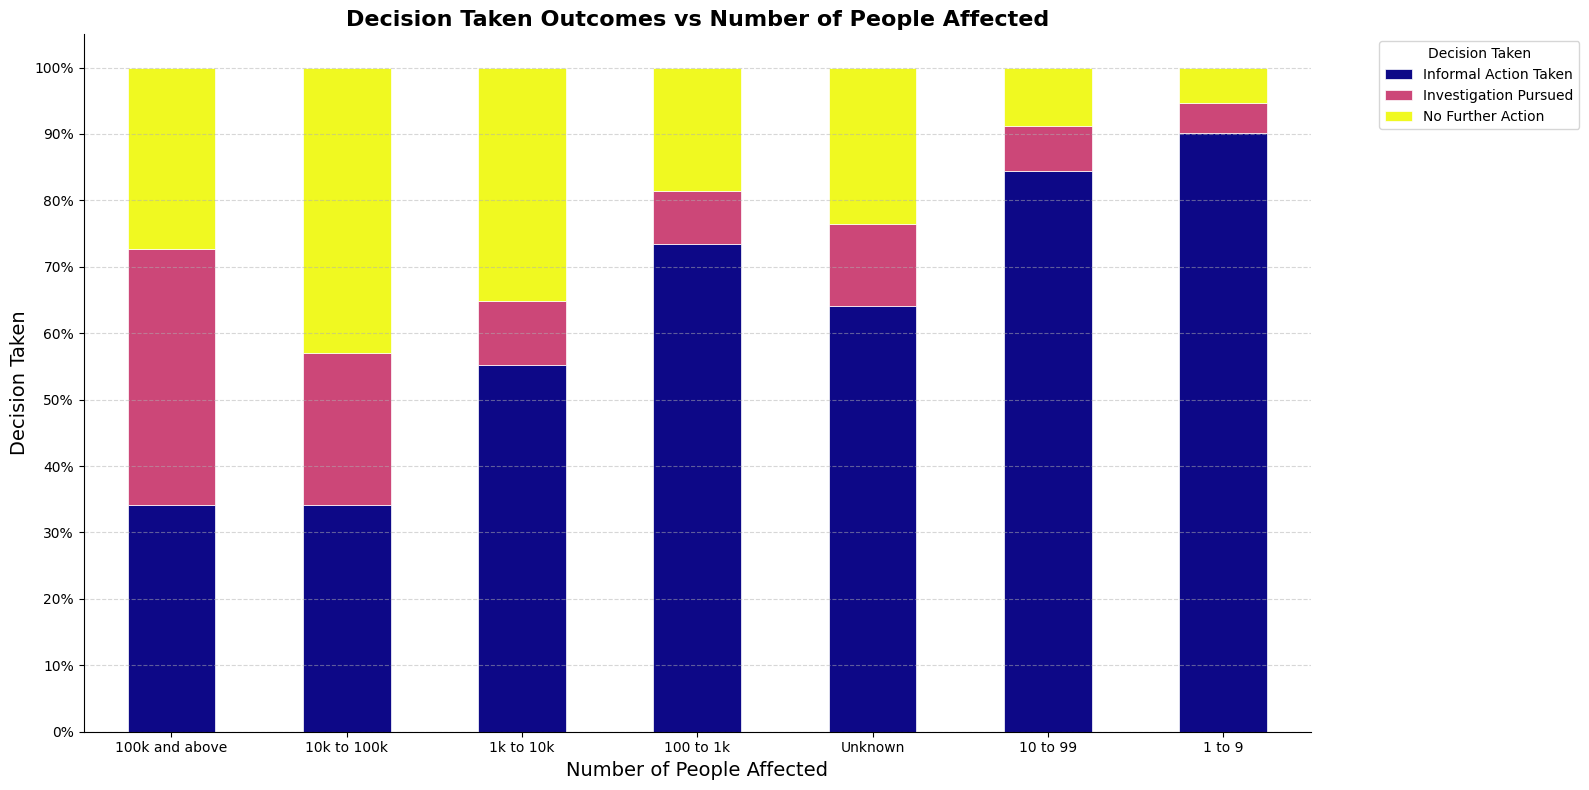

decision_taken             Informal Action Taken  Investigation Pursued  \
no_data_subjects_affected                                                 
100k and above                             0.341                  0.386   
10k to 100k                                0.341                  0.230   
1k to 10k                                  0.553                  0.095   
100 to 1k                                  0.734                  0.079   
Unknown                                    0.641                  0.123   
10 to 99                                   0.844                  0.068   
1 to 9                                     0.901                  0.045   

decision_taken             No Further Action  
no_data_subjects_affected                     
100k and above                         0.273  
10k to 100k                            0.430  
1k to 10k                              0.352  
100 to 1k                              0.187  
Unknown                                0.2

In [20]:
# Decision taken vs No. of people affected
proportions, counts = plot_vertical_stacked_crosstab(
    df_health_unique["no_data_subjects_affected"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Number of People Affected",
    xlabel="Decision Taken",
    ylabel="Number of People Affected",
)
print(proportions)

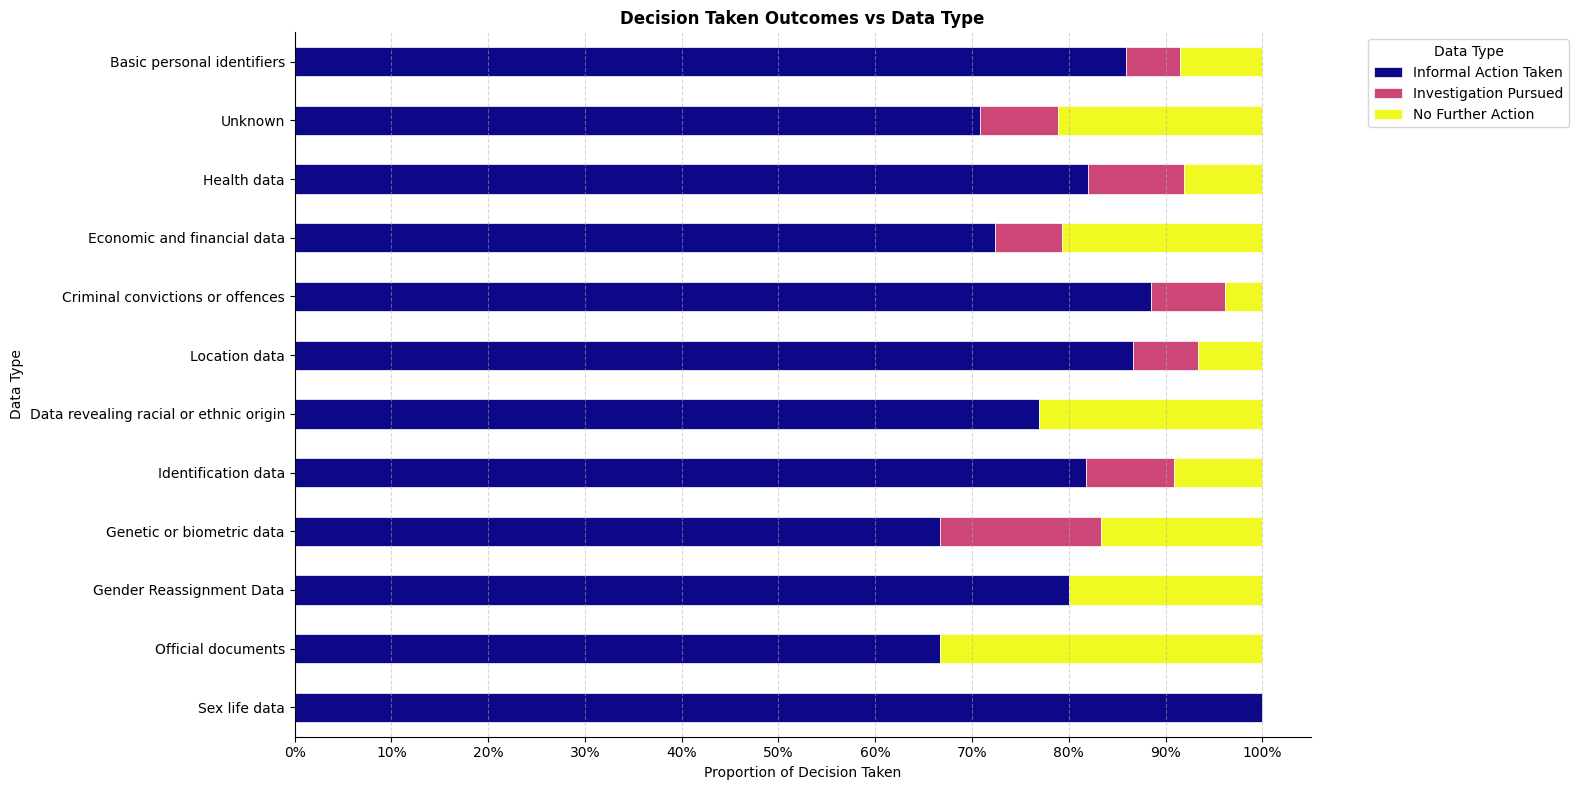

decision_taken                          Informal Action Taken  \
data_type                                                       
Sex life data                                           1.000   
Official documents                                      0.667   
Gender Reassignment Data                                0.800   
Genetic or biometric data                               0.667   
Identification data                                     0.818   
Data revealing racial or ethnic origin                  0.769   
Location data                                           0.867   
Criminal convictions or offences                        0.885   
Economic and financial data                             0.724   
Health data                                             0.820   
Unknown                                                 0.709   
Basic personal identifiers                              0.859   

decision_taken                          Investigation Pursued  \
data_type               

In [21]:
# Decision taken vs data type 
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["data_type"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Data Type",
    xlabel="Decision Taken",
    ylabel="Data Type",
)
print(proportions)

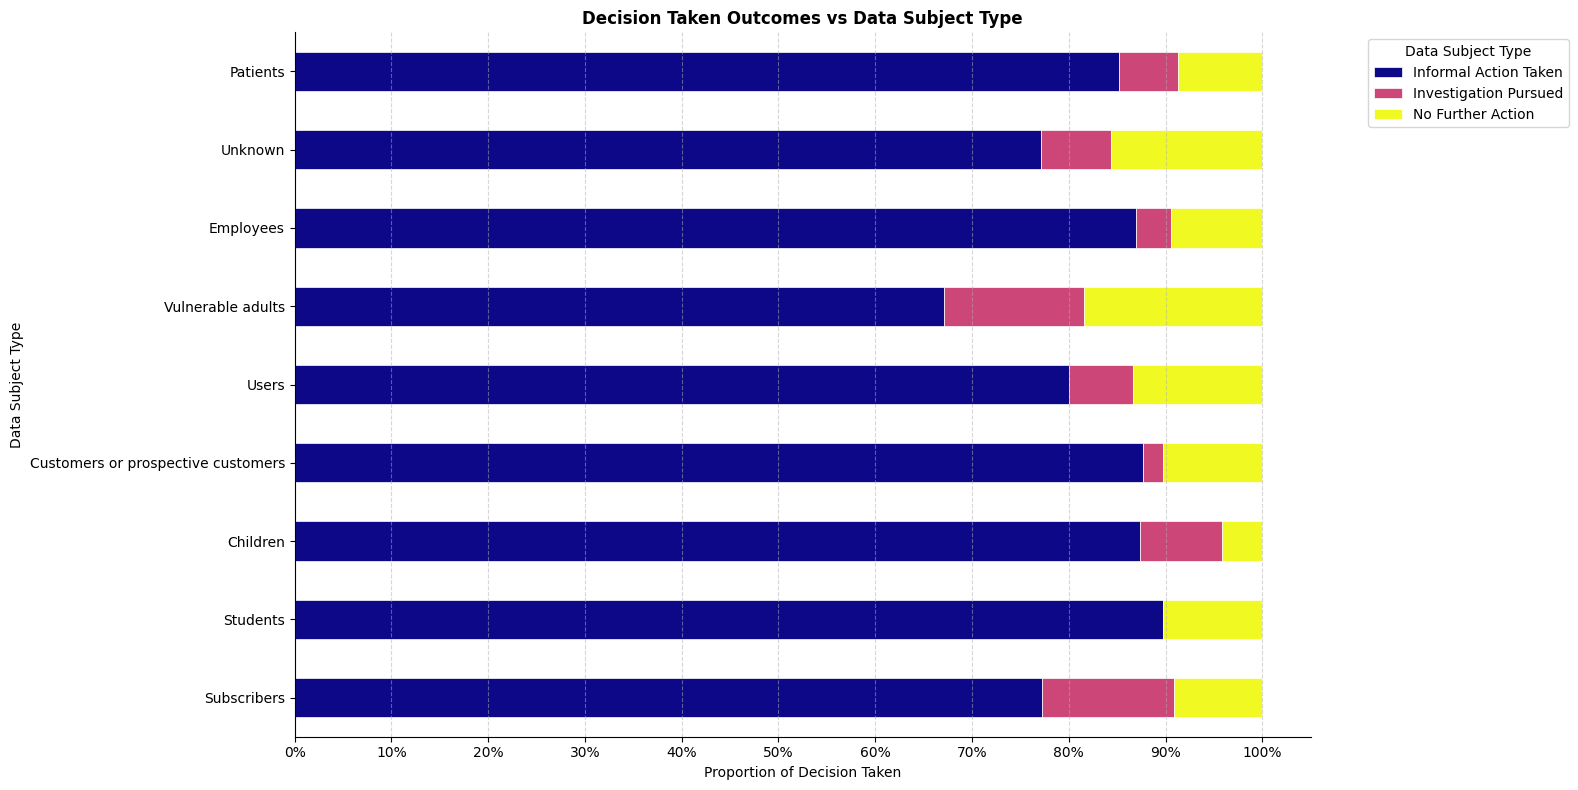

decision_taken                      Informal Action Taken  \
data_subject_type                                           
Subscribers                                         0.773   
Students                                            0.897   
Children                                            0.874   
Customers or prospective customers                  0.877   
Users                                               0.801   
Vulnerable adults                                   0.671   
Employees                                           0.870   
Unknown                                             0.771   
Patients                                            0.852   

decision_taken                      Investigation Pursued  No Further Action  
data_subject_type                                                             
Subscribers                                         0.136              0.091  
Students                                            0.000              0.103  
Children    

In [22]:
# Decision taken vs data subject type
proportions, counts = plot_horizontal_stacked_crosstab(
    df_health_unique["data_subject_type"],
    df_health_unique["decision_taken"],
    title="Decision Taken Outcomes vs Data Subject Type",
    xlabel="Decision Taken",
    ylabel="Data Subject Type",
)
print(proportions)

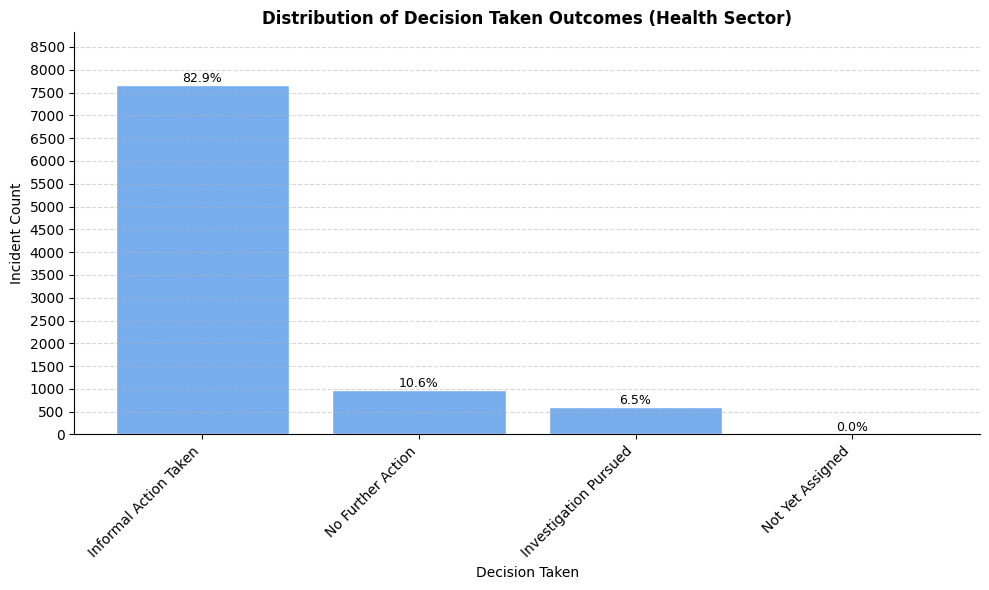

                       count  percentage
decision_taken                          
Informal Action Taken   7670   82.918919
No Further Action        982   10.616216
Investigation Pursued    598    6.464865
Not Yet Assigned           0    0.000000


In [23]:
# Distribution of decision taken outcomes
decision_summary = plot_vertical_bar_chart(
    df_health_unique["decision_taken"].value_counts(),
    title="Distribution of Decision Taken Outcomes (Health Sector)",
    xlabel="Decision Taken",
    ylabel="Incident Count",
    sort_by="none",
    annotate="percentage",
    colour="#78ADED",
    step=500,
)
print(decision_summary)

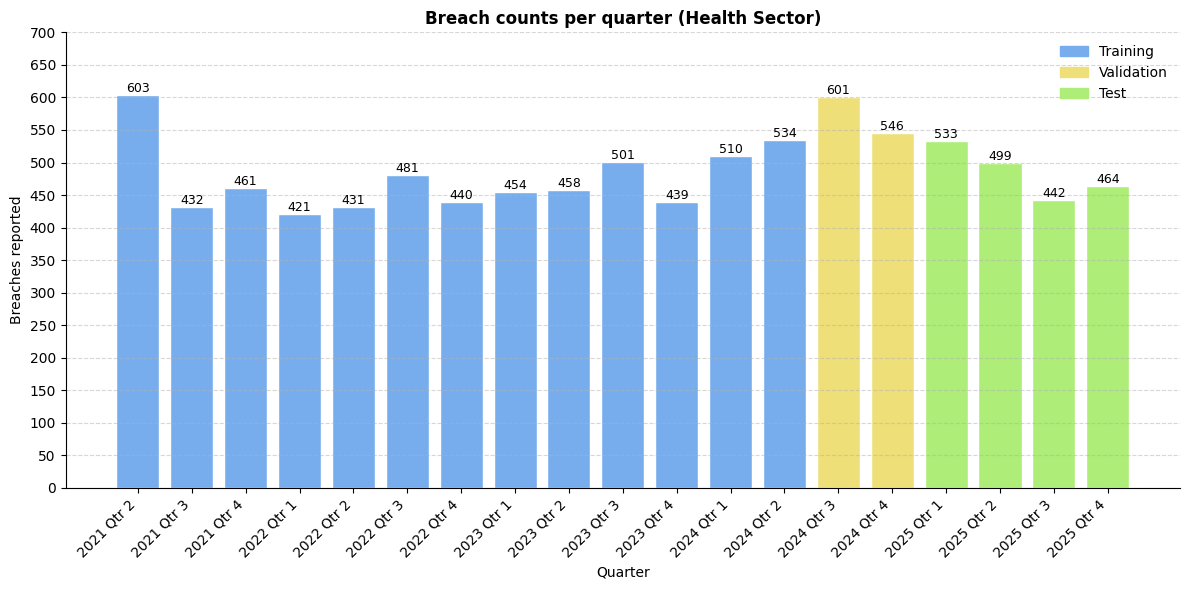

,year,quarter,period,count,partition
0,2021,Qtr 2,2021 Qtr 2,603,Training
1,2021,Qtr 3,2021 Qtr 3,432,Training
2,2021,Qtr 4,2021 Qtr 4,461,Training
3,2022,Qtr 1,2022 Qtr 1,421,Training
4,2022,Qtr 2,2022 Qtr 2,431,Training
5,2022,Qtr 3,2022 Qtr 3,481,Training
6,2022,Qtr 4,2022 Qtr 4,440,Training
7,2023,Qtr 1,2023 Qtr 1,454,Training
8,2023,Qtr 2,2023 Qtr 2,458,Training
9,2023,Qtr 3,2023 Qtr 3,501,Training


In [25]:
from src.visualisations import plot_partition_bar_chart

plot_partition_bar_chart(
    df_health_unique,
    title="Breach counts per quarter (Health Sector)",   
    val_quarters=VAL_QUARTERS,
    val_year=VAL_YEAR,
    test_year=TEST_YEAR,
    train_years= list(TRAIN_YEARS),
    step=50
)